## Exploratory Data Analysis (EDA)

Exploratory Data Analysis was performed to understand the structure and characteristics of the Glass dataset. The dataset was examined using functions like `head()`, `info()`, `shape()`, and `describe()` to analyze the number of rows, columns, data types, and statistical summaries. This step helps identify inconsistencies, missing values, duplicate records, and overall data quality before model building.

In [33]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [61]:
from sklearn.preprocessing import LabelEncoder,OneHotEncoder,StandardScaler
from sklearn.model_selection import train_test_split,GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import BaggingClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.metrics import accuracy_score,f1_score,classification_report,confusion_matrix


df=pd.read_excel(r'glass.xlsx')
xls=pd.ExcelFile(r'glass.xlsx')
for sheet in xls.sheet_names:
    df=pd.read_excel(r'glass.xlsx',sheet_name=sheet)
    df.head()
df.head()

,RI,Na,Mg,Al,Si,K,Ca,Ba,Fe,Type
0,1.52101,13.64,4.49,1.10,71.78,0.06,8.75,0.0,0.0,1
1,1.51761,13.89,3.60,1.36,72.73,0.48,7.83,0.0,0.0,1
2,1.51618,13.53,3.55,1.54,72.99,0.39,7.78,0.0,0.0,1
3,1.51766,13.21,3.69,1.29,72.61,0.57,8.22,0.0,0.0,1
4,1.51742,13.27,3.62,1.24,73.08,0.55,8.07,0.0,0.0,1


In [35]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 214 entries, 0 to 213
Data columns (total 10 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   RI      214 non-null    float64
 1   Na      214 non-null    float64
 2   Mg      214 non-null    float64
 3   Al      214 non-null    float64
 4   Si      214 non-null    float64
 5   K       214 non-null    float64
 6   Ca      214 non-null    float64
 7   Ba      214 non-null    float64
 8   Fe      214 non-null    float64
 9   Type    214 non-null    int64  
dtypes: float64(9), int64(1)
memory usage: 16.8 KB


In [36]:
df.shape

(214, 10)

In [37]:
df.columns

Index(['RI', 'Na', 'Mg', 'Al', 'Si', 'K', 'Ca', 'Ba', 'Fe', 'Type'], dtype='object')

In [38]:
df.describe()

,RI,Na,Mg,Al,Si,K,Ca,Ba,Fe,Type
count,214.000000,214.000000,214.000000,214.000000,214.000000,214.000000,214.000000,214.000000,214.000000,214.000000
mean,1.518365,13.407850,2.684533,1.444907,72.650935,0.497056,8.956963,0.175047,0.057009,2.780374
std,0.003037,0.816604,1.442408,0.499270,0.774546,0.652192,1.423153,0.497219,0.097439,2.103739
min,1.511150,10.730000,0.000000,0.290000,69.810000,0.000000,5.430000,0.000000,0.000000,1.000000
25%,1.516522,12.907500,2.115000,1.190000,72.280000,0.122500,8.240000,0.000000,0.000000,1.000000
50%,1.517680,13.300000,3.480000,1.360000,72.790000,0.555000,8.600000,0.000000,0.000000,2.000000
75%,1.519157,13.825000,3.600000,1.630000,73.087500,0.610000,9.172500,0.000000,0.100000,3.000000
max,1.533930,17.380000,4.490000,3.500000,75.410000,6.210000,16.190000,3.150000,0.510000,7.000000


## Histogram Visualization

Histograms were created to visualize the distribution of numerical features in the dataset. This helps identify skewness, spread, frequency distribution, and unusual patterns within the variables. Understanding feature distribution is important before applying machine learning algorithms.

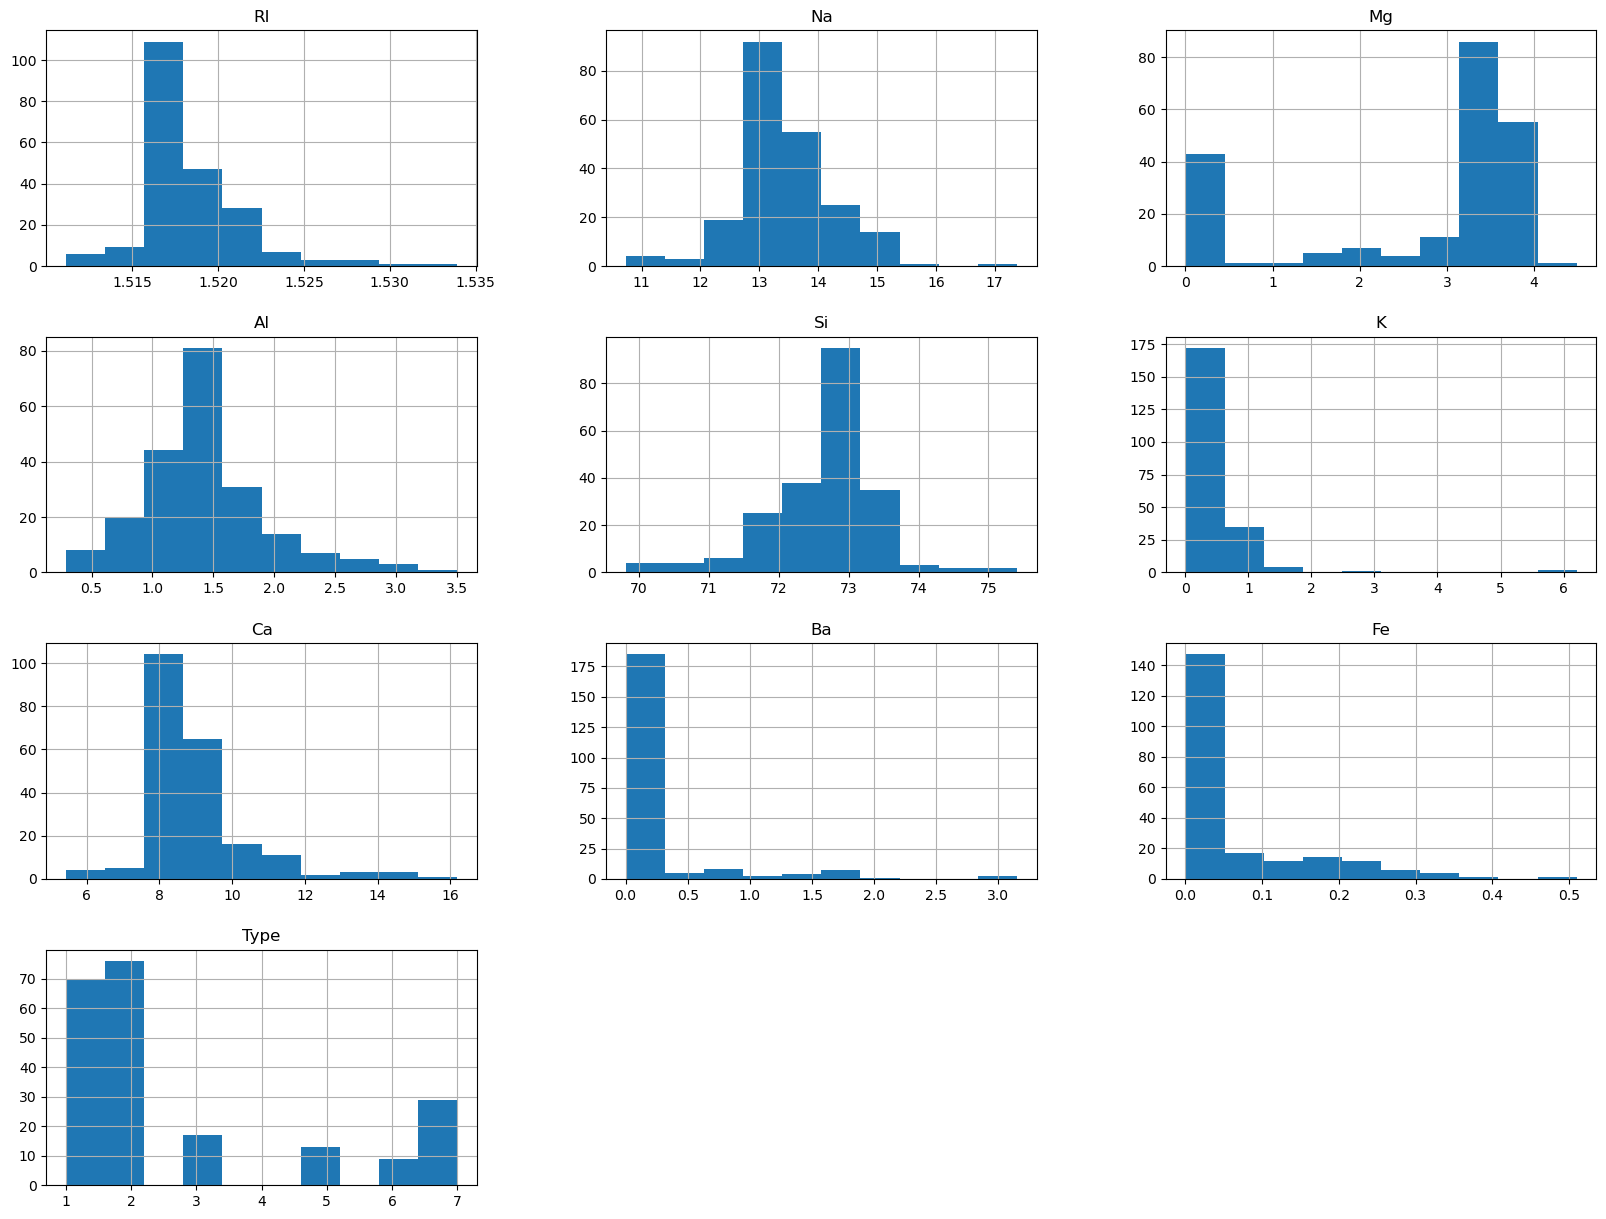

In [41]:
df.hist(figsize=(20,15))
plt.show()

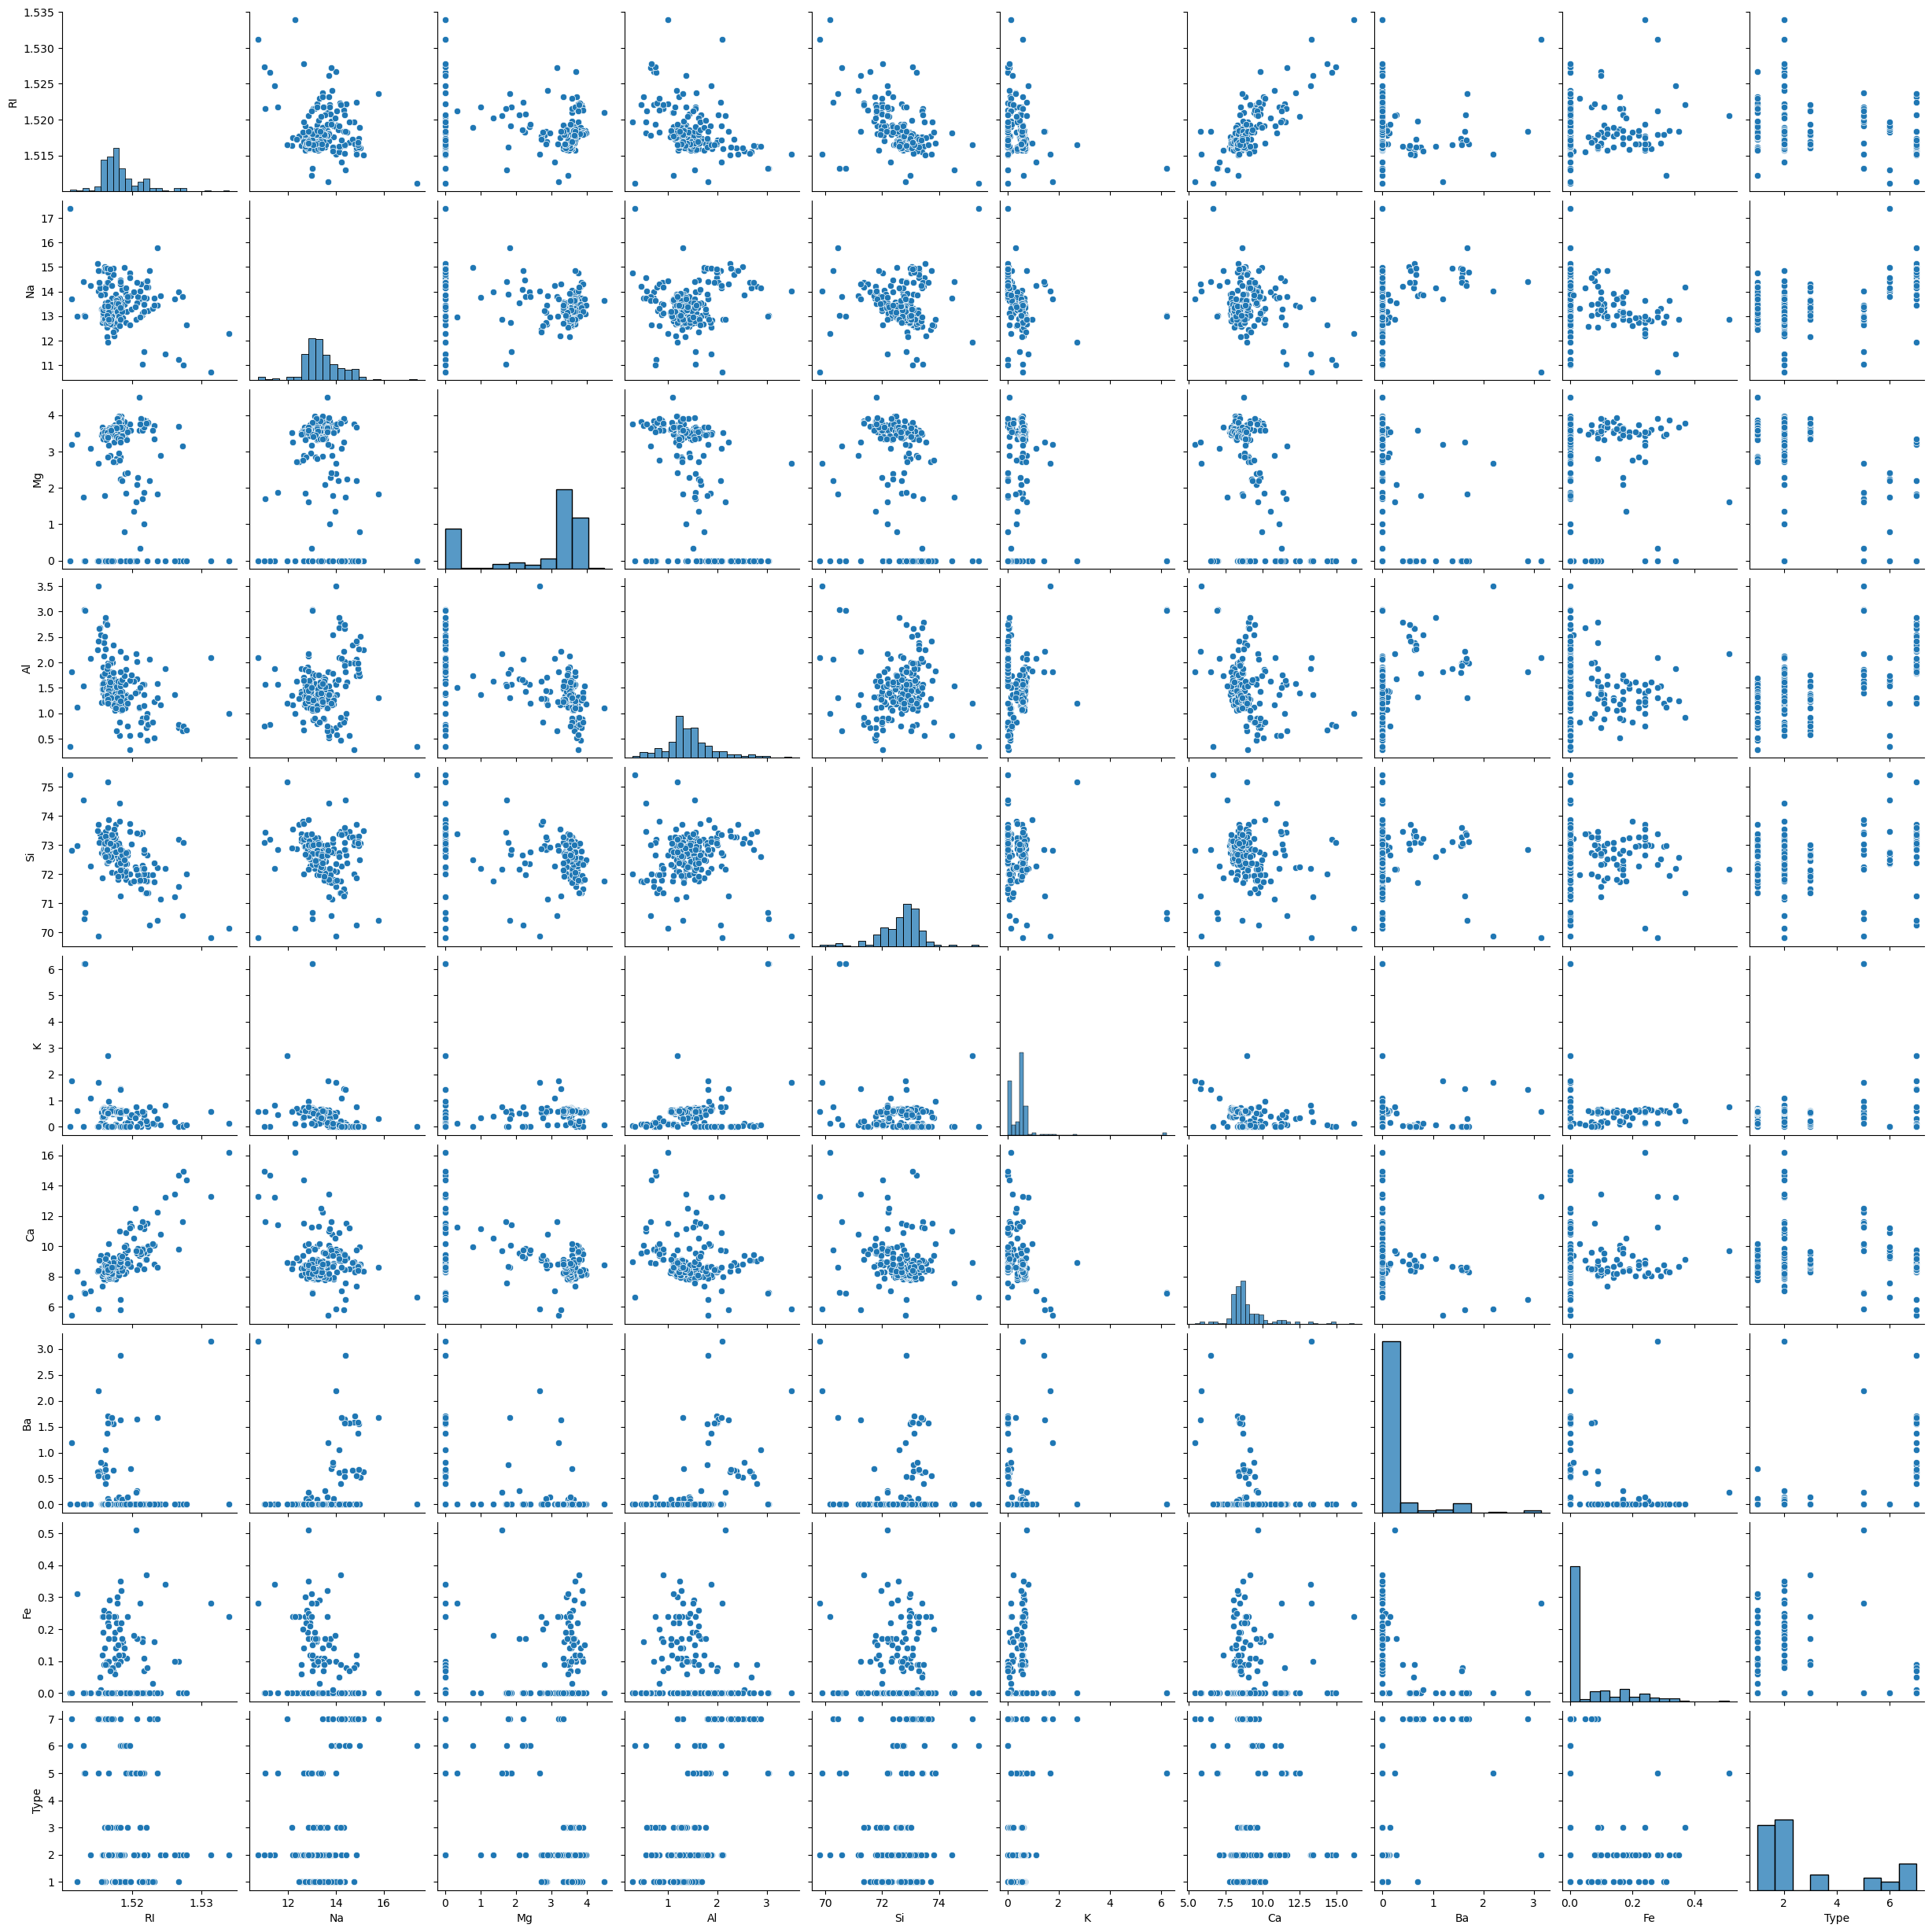

In [42]:
sns.pairplot(data=df)
plt.show()

## Box Plot Visualization

Box plots were used to detect outliers in the dataset. Outliers are extreme values that differ significantly from other observations and may affect model performance. Random Forest models are generally robust to outliers, but analyzing them is still an important preprocessing step.

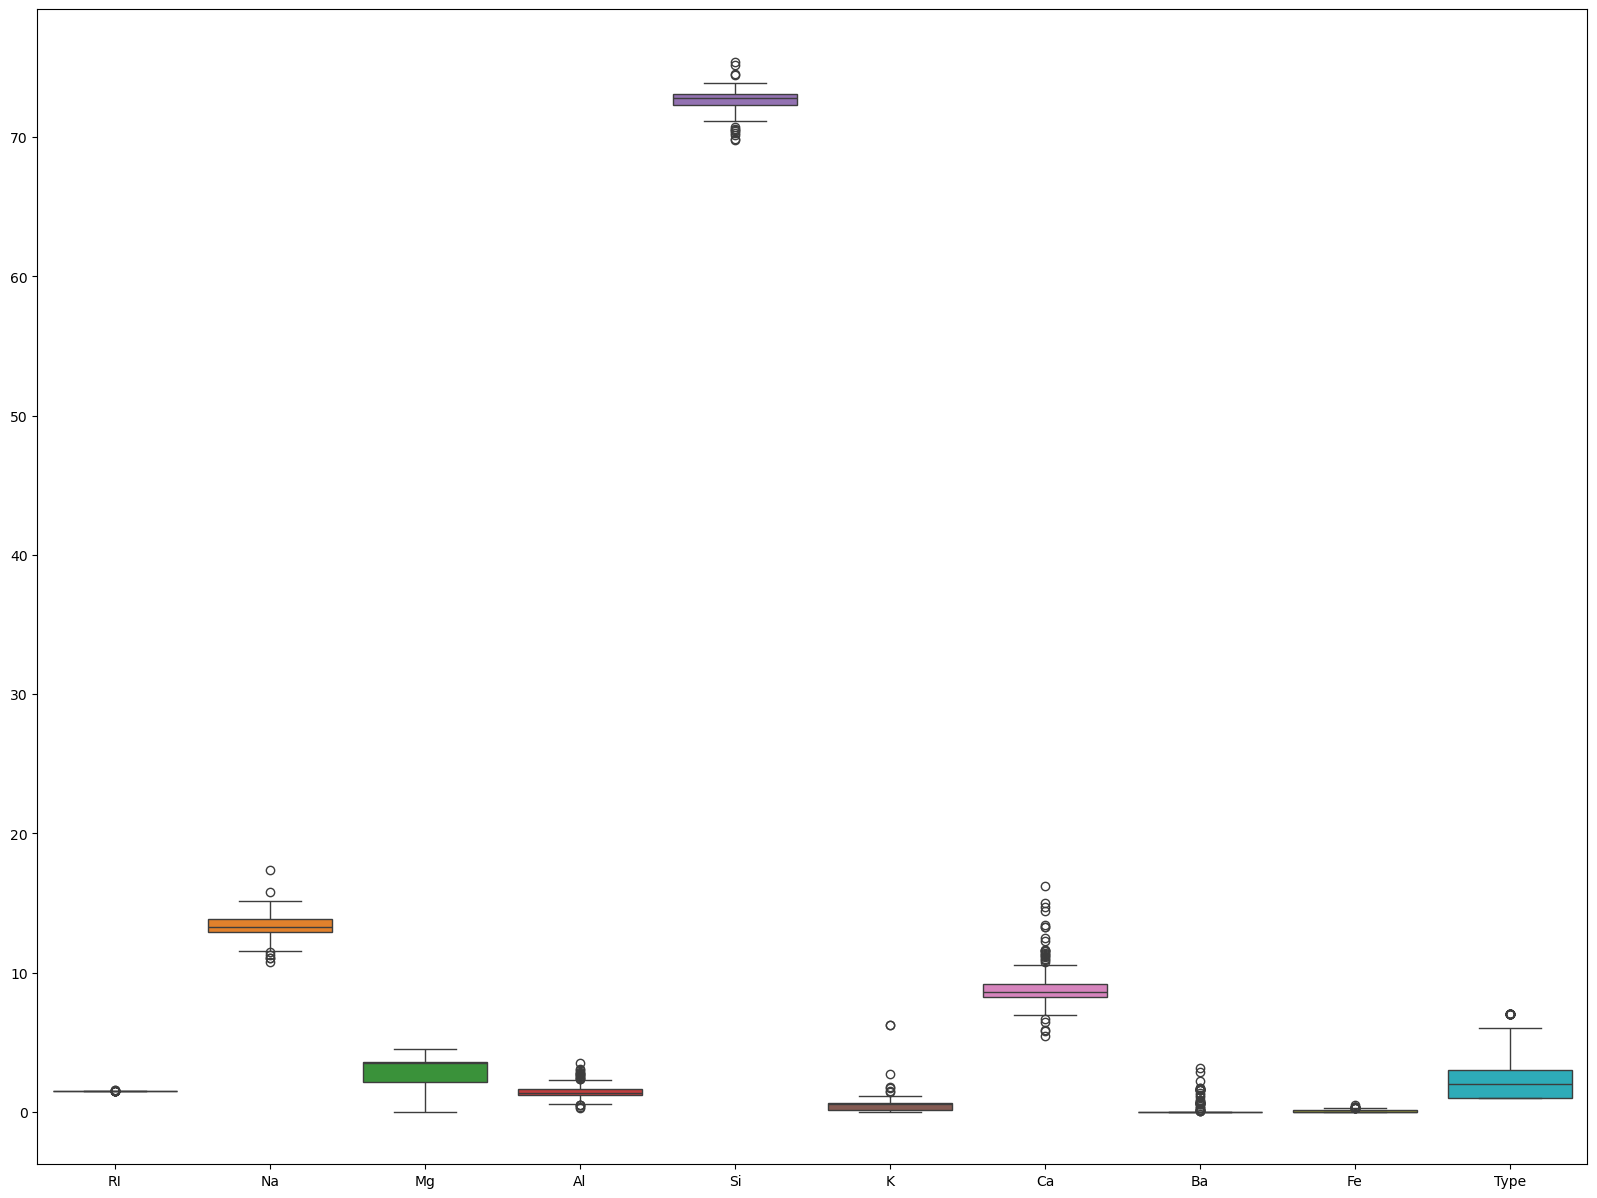

In [43]:
plt.figure(figsize=(20,15))
sns.boxplot(data=df)
plt.show()

In [44]:
df.skew()

RI      1.625431
Na      0.454181
Mg     -1.152559
Al      0.907290
Si     -0.730447
K       6.551648
Ca      2.047054
Ba      3.416425
Fe      1.754327
Type    1.114915
dtype: float64

## Correlation Heatmap

A correlation heatmap was generated to analyze relationships between different features. Correlation values indicate how strongly variables are related to one another. Highly correlated features may contain redundant information, while weak correlations indicate independent features.

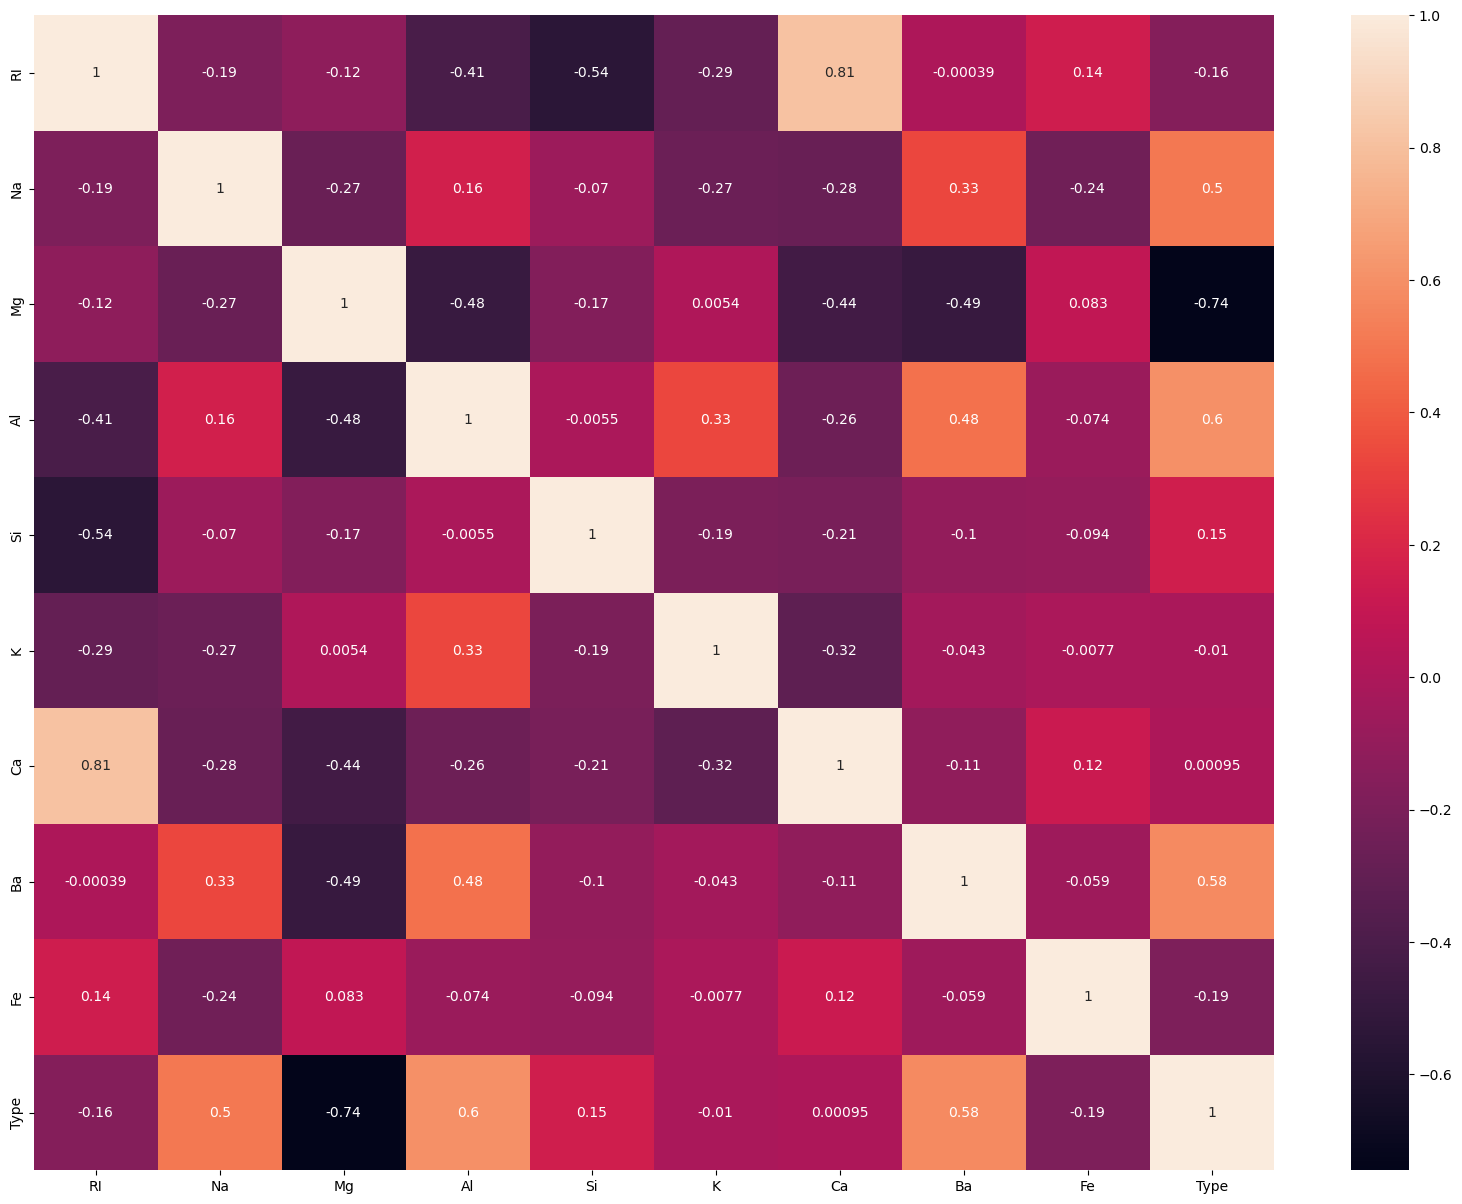

In [48]:
plt.figure(figsize=(20,15))
sns.heatmap(df.corr(),annot=True)
plt.show()

## Missing Value Analysis

The dataset was checked for missing values using `isnull().sum()`. Missing values can negatively impact machine learning model performance and may lead to inaccurate predictions. Since the Glass dataset does not contain missing values, no imputation techniques were required.

In [49]:
df.isnull().sum()

RI      0
Na      0
Mg      0
Al      0
Si      0
K       0
Ca      0
Ba      0
Fe      0
Type    0
dtype: int64

## Duplicate Value Analysis

Duplicate records were identified using `duplicated().sum()`. Duplicate rows can introduce bias into the model and affect prediction accuracy. Any duplicate values found were removed to improve dataset quality and ensure reliable model training.

In [50]:
df.duplicated().sum()

np.int64(1)

In [53]:
df['Type'].value_counts()

Type
2    76
1    70
7    29
3    17
5    13
6     9
Name: count, dtype: int64

## Feature and Target Separation

The independent variables were separated into feature matrix `X`, while the dependent variable was assigned to target variable `y`. This separation is necessary because machine learning models learn patterns from input features to predict the target class.

In [77]:
X=df.drop('Type',axis=1)
y=df['Type']

## Data Preprocessing

Data preprocessing was performed to prepare the dataset for machine learning model training. Preprocessing improves data quality, consistency, and model performance.

In [57]:
ss=StandardScaler()
scaled_x=ss.fit_transform(X)
scaled_x

array([[ 0.87286765,  0.28495326,  1.25463857, ..., -0.14576634,
        -0.35287683, -0.5864509 ],
       [-0.24933347,  0.59181718,  0.63616803, ..., -0.79373376,
        -0.35287683, -0.5864509 ],
       [-0.72131806,  0.14993314,  0.60142249, ..., -0.82894938,
        -0.35287683, -0.5864509 ],
       ...,
       [ 0.75404635,  1.16872135, -1.86551055, ..., -0.36410319,
         2.95320036, -0.5864509 ],
       [-0.61239854,  1.19327046, -1.86551055, ..., -0.33593069,
         2.81208731, -0.5864509 ],
       [-0.41436305,  1.00915211, -1.86551055, ..., -0.23732695,
         3.01367739, -0.5864509 ]], shape=(214, 9))

In [64]:
train_x,test_x,train_y,test_y=train_test_split(scaled_x,y,test_size=0.2,random_state=42)

## Random Forest Model

Random Forest is an ensemble machine learning algorithm that combines multiple decision trees to improve prediction accuracy and reduce overfitting. Each tree is trained on random subsets of the data and features, and the final prediction is determined using majority voting.
## Model Training

The Random Forest classifier was trained using the training dataset. During training, the algorithm learned patterns and relationships between chemical properties of glass samples and their corresponding glass types.

In [65]:
rf=RandomForestClassifier(n_estimators=100,random_state=42)
rf.fit(train_x,train_y)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


## Model Prediction

After training, predictions were generated on the testing dataset. These predictions were compared with actual values to evaluate model performance.

In [71]:
y_predict=rf.predict(test_x)
accuracy=accuracy_score(test_y,y_predict)
print(accuracy)
cr=classification_report(test_y,y_predict)
print(cr)
cm=confusion_matrix(test_y,y_predict)
print(cm)

0.8372093023255814
              precision    recall  f1-score   support

           1       0.69      1.00      0.81        11
           2       0.90      0.64      0.75        14
           3       1.00      0.67      0.80         3
           5       1.00      0.75      0.86         4
           6       1.00      1.00      1.00         3
           7       0.89      1.00      0.94         8

    accuracy                           0.84        43
   macro avg       0.91      0.84      0.86        43
weighted avg       0.87      0.84      0.83        43

[[11  0  0  0  0  0]
 [ 4  9  0  0  0  1]
 [ 1  0  2  0  0  0]
 [ 0  1  0  3  0  0]
 [ 0  0  0  0  3  0]
 [ 0  0  0  0  0  8]]


## Bagging Method

Bagging, also known as Bootstrap Aggregating, is an ensemble learning technique that trains multiple models independently using random subsets of the dataset. The final prediction is obtained by combining outputs from all models through majority voting.
## Advantages of Bagging

- Reduces variance
- Improves stability
- Minimizes overfitting

In [73]:
bag=BaggingClassifier(n_estimators=100,random_state=42)
bag.fit(train_x,train_y)
y_predict=bag.predict(test_x)
accuracy=accuracy_score(test_y,y_predict)
print(accuracy)
cr=classification_report(test_y,y_predict)
print(cr)
cm=confusion_matrix(test_y,y_predict)
print(cm)

0.8604651162790697
              precision    recall  f1-score   support

           1       0.79      1.00      0.88        11
           2       0.91      0.71      0.80        14
           3       0.50      0.33      0.40         3
           5       1.00      1.00      1.00         4
           6       1.00      1.00      1.00         3
           7       0.89      1.00      0.94         8

    accuracy                           0.86        43
   macro avg       0.85      0.84      0.84        43
weighted avg       0.86      0.86      0.85        43

[[11  0  0  0  0  0]
 [ 2 10  1  0  0  1]
 [ 1  1  1  0  0  0]
 [ 0  0  0  4  0  0]
 [ 0  0  0  0  3  0]
 [ 0  0  0  0  0  8]]


## Boosting Method

Boosting is an ensemble technique where models are trained sequentially. Each new model focuses on correcting errors made by previous models. Weak learners combine together to form a strong predictive model.
## Advantages of Boosting

- Reduces bias
- Improves prediction accuracy
- Learns difficult patterns effectively

In [74]:
ada=AdaBoostClassifier(n_estimators=100,random_state=42)
ada.fit(train_x,train_y)
y_predict=ada.predict(test_x)
accuracy=accuracy_score(test_y,y_predict)
print(accuracy)
cr=classification_report(test_y,y_predict)
print(cr)
cm=confusion_matrix(test_y,y_predict)
print(cm)

0.627906976744186
              precision    recall  f1-score   support

           1       0.67      0.73      0.70        11
           2       0.59      0.71      0.65        14
           3       0.00      0.00      0.00         3
           5       0.33      0.25      0.29         4
           6       0.50      0.67      0.57         3
           7       1.00      0.75      0.86         8

    accuracy                           0.63        43
   macro avg       0.51      0.52      0.51        43
weighted avg       0.61      0.63      0.61        43

[[ 8  3  0  0  0  0]
 [ 2 10  1  1  0  0]
 [ 2  1  0  0  0  0]
 [ 0  3  0  1  0  0]
 [ 0  0  0  1  2  0]
 [ 0  0  0  0  2  6]]


## Difference Between Bagging and Boosting

| Bagging | Boosting |
|---|---|
| Models are trained independently | Models are trained sequentially |
| Reduces variance | Reduces bias |
| Parallel learning | Sequential learning |
| Less sensitive to noise | More sensitive to noise |
| Example: Random Forest | Example: AdaBoost |

## Techniques for Handling Imbalanced Data

- Oversampling
- Undersampling
- SMOTE (Synthetic Minority Oversampling Technique)
- Class weighting